#KNN

In [57]:
import pandas as pd

df = pd.read_csv('winequality-red.csv', sep=';')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


## 1- Preparação dos dados: carregue odataset e recodifique a variável quality em trêss classes: notas ≤ 5 como ruim, 6–7 como médio e ≥ 8 como bom. Em seguida, normalize todos os atributos utilizando Min-Max ou Z-score. Justifique por que a normalização é uma etapa obrigatória para o 𝑘-NN.

In [58]:
x = df.drop(columns=['quality'])
y = df['quality']

x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [59]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
1594,5
1595,6
1596,6
1597,5


In [60]:
y.value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


In [61]:
y_ruins = len(list(filter(lambda ruins: ruins<=5, y)))
print(f"Quantidade de notas ruins: {y_ruins}")

Quantidade de notas ruins: 744


In [62]:
y_medios = len(list(filter(lambda medios: medios == 6 or medios ==7, y)))
print(f"Quantidade de notas médios: {y_medios}")

Quantidade de notas médios: 837


In [63]:
y_bom = len(list(filter(lambda bom: bom>=8, y)))
print(f"Quantidade de notas boas: {y_bom}")

Quantidade de notas boas: 18


In [64]:
classes = []
for nota in y:
  if nota <= 5:
    classes.append('Ruim')
  elif nota == 6 or nota == 7:
    classes.append('Médio')
  else:
    classes.append('bom')

df_classes = pd.DataFrame(classes, columns=['Classes'])
y = df_classes
y


,Classes
0,Ruim
1,Ruim
2,Ruim
3,Médio
4,Ruim
...,...
1594,Ruim
1595,Médio
1596,Médio
1597,Ruim


Melhores ocasiões para o uso de cada um dela

|Critérios|Z-score|Min-Max-Scaling|
|:---|:---|:---|
|Outliers|Lida Melhor|Sensível|
|Distribuição|Normal(Ideal)|Qualquer|
|Interpretação|Média = 0|Escala fixa|
|Uso comum|Estatística/ML|Deep Learning|

A normalização é obrigatória no k-NN porque o algoritmo utiliza medidas de distância. Sem normalizar, atributos com maior escala dominam o cálculo, prejudicando a identificação dos vizinhos mais próximos e comprometendo a precisão do modelo.
Porem deixei para realizar a normalização junto com o bloco de código de divisão e teste

## 2- Divisão treino/teste: divida os dados em 80% para treino e 20% para teste, utilizando divisão estratificada para garantir que a proporção das três classes seja mantida em ambos os conjuntos.

Resultados:

Min-Max-sacaling = [0, 1] → $x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$

In [65]:
# slplit tem que ser antes da normalização

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

y = df_classes['Classes']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#Normalização min-max
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print(f"Quantidade de dados de treino: {len(x_train)}")
print(f"Quantidade de dados de teste: {len(x_test)}")
print(f"Quantidades total de dados: {len(x_train) + len(x_test)}")

Quantidade de dados de treino: 1279
Quantidade de dados de teste: 320
Quantidades total de dados: 1599


## 3- Treinamento e escolha do 𝑘: treine o modelo para diferentes valores de 𝑘 (ex: 1, 3, 5, 7, 11) utilizando validação cruzada de 5 folds sobre o conjunto de treino. Plote a acurácia média em função de 𝑘 e escolha o valor com melhor desempenho. O que acontece com o modelo para valores muito baixos e muito altos de 𝑘?

Acurácia para k = 1: 0.7123
Acurácia para k = 2: 0.6794
Acurácia para k = 3: 0.6834
Acurácia para k = 4: 0.6787
Acurácia para k = 5: 0.6912
Acurácia para k = 6: 0.6787
Acurácia para k = 7: 0.6857
Acurácia para k = 8: 0.6779
Acurácia para k = 9: 0.6982
Acurácia para k = 10: 0.6959
Acurácia para k = 11: 0.7068
Acurácia para k = 12: 0.699
Acurácia para k = 13: 0.7021
Acurácia para k = 14: 0.7092
Acurácia para k = 15: 0.7092
Acurácia para k = 16: 0.7076
Acurácia para k = 17: 0.717
Acurácia para k = 18: 0.7154
Acurácia para k = 19: 0.7178
Acurácia para k = 20: 0.717
Acurácia para k = 21: 0.7154


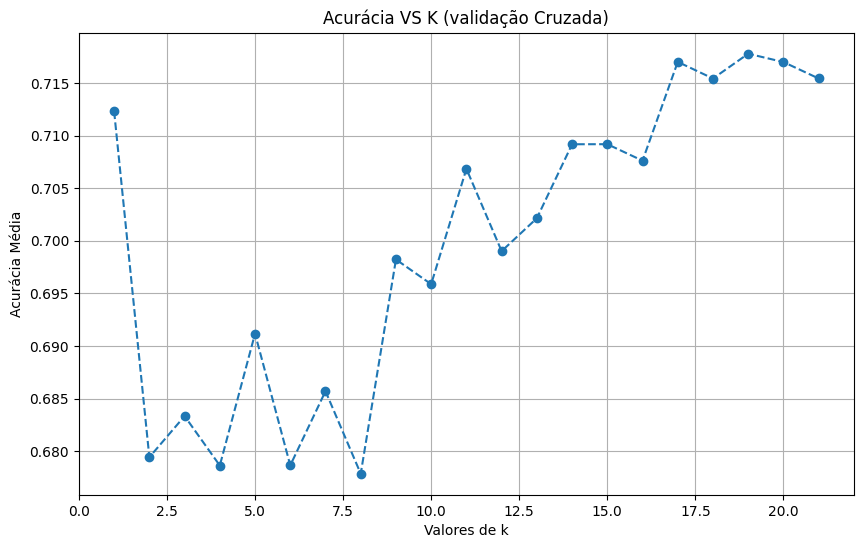

Melhor K: 19


In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

k_valores = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
media_acuracia = []

for k in k_valores:
  knn = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(
      knn,
      x_train,
      y_train,
      cv = 5,
      scoring = 'accuracy'
  )
  acuracia_media = scores.mean()
  media_acuracia.append(acuracia_media)

  print(f"Acurácia para k = {k}: {acuracia_media.round(4)}")

plt.figure(figsize=(10, 6))
plt.plot(k_valores, media_acuracia, marker = 'o', linestyle = '--')
#plt.xticks(list(range(0,max(k_valores)+1)))
plt.xlabel('Valores de k')
plt.ylabel('Acurácia Média')
plt.title('Acurácia VS K (validação Cruzada)')
plt.grid()
plt.show()

#melhor K
melhor_k = k_valores[media_acuracia.index(max(media_acuracia))]
print(f"Melhor K: {melhor_k}")

Para valores muito baixos de k, o modelo torna-se altamente sensível aos dados de treinamento, podendo aprender ruídos e apresentar overfitting (alta variância). Já para valores muito altos de k, o modelo passa a considerar muitos vizinhos, perdendo a capacidade de capturar padrões locais e apresentando underfitting (alto viés). O valor ideal de k é aquele que equilibra esses dois comportamentos, proporcionando melhor generalização.

## 4- Avaliação do modelo: utilizando o conjunto de teste — reservado exclusivamente para esta etapa — calcule a matriz de confusão e as métricas de acurácia, precisão, recall e F1-score para cada classe. Responda: Entre quais classes o modelo erra com mais frequência?

Acurácia no conjunto de teste: 0.7562

Relatório de Classificação:
              precision    recall  f1-score   support

       Médio       0.74      0.81      0.78       167
        Ruim       0.77      0.71      0.74       149
         bom       0.00      0.00      0.00         4

    accuracy                           0.76       320
   macro avg       0.51      0.51      0.51       320
weighted avg       0.75      0.76      0.75       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


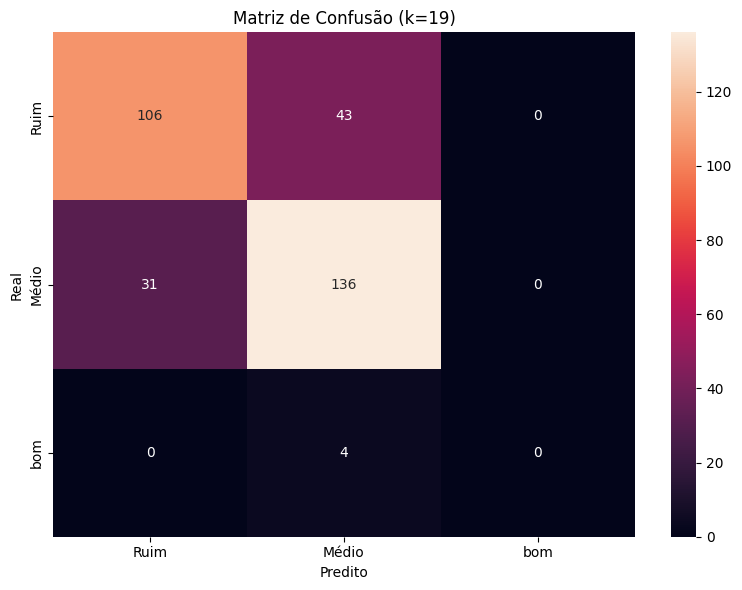

In [67]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

#treino com o melhor k encontrado na validação cruzada
knn_final = KNeighborsClassifier(n_neighbors=17)
knn_final.fit(x_train, y_train)

# Predições no conjunto de teste
y_pred = knn_final.predict(x_test)

# Acurácia
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {acuracia:.4f}")

# Relatório de classificação (precisão, recall, F1-score por classe)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Matriz de confusão
labels = ['Ruim', 'Médio', 'bom']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title(f'Matriz de Confusão (k={melhor_k})')
plt.tight_layout()
plt.show()


$\cdot$ `support` = QTD de exemplos reais em cada classe  
$\cdot$ `macro avg` = Média simples entre as classes  
$\cdot$ `weighted avg` = Média ponderada pelo número de exemplos (`support`)

`macro avg` → trata todas as classes igualmente  
`weighted avg` → considera o tamanho das classes

O modelo apresenta maior frequência de erro entre as classes Ruim e Médio, especialmente classificando amostras de Ruim como Médio (43 casos) e de Médio como Ruim (31 casos).